图像1特征点：2000 个 | 图像2特征点：2000 个
比值筛选后优质匹配：299 个


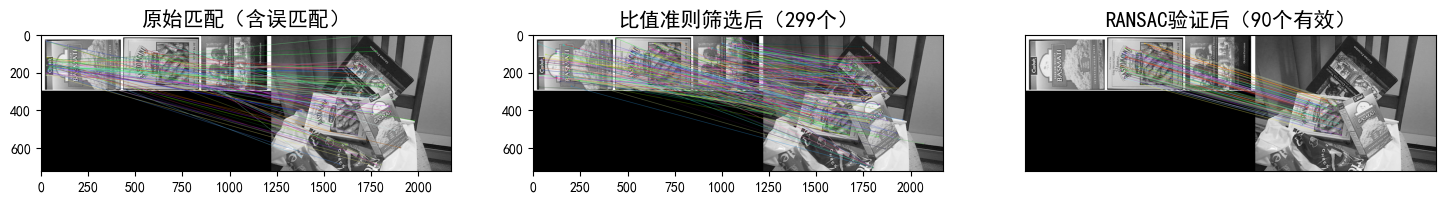

RANSAC验证后有效匹配：90 个
单应性矩阵：
 [[ 6.11000e-01 -2.14000e-01 -6.12470e+01]
 [-4.00000e-03  5.74000e-01  2.69788e+02]
 [-0.00000e+00 -0.00000e+00  1.00000e+00]]


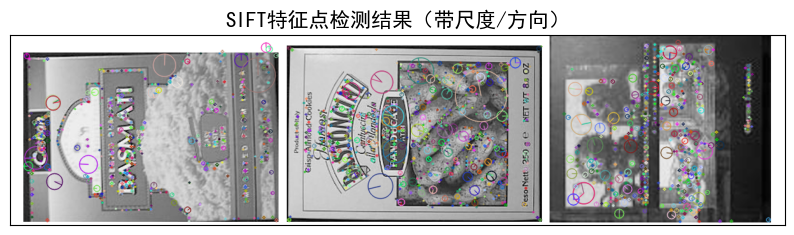

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 初始化SIFT检测器
sift = cv2.SIFT_create(
    nfeatures=2000,
    nOctaveLayers=3,
    contrastThreshold=0.04,
    edgeThreshold=10,
    sigma=1.6
)

# 提取SIFT特征点和描述符
def extract_sift_features(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)
    return gray, kp, des

# 特征匹配+近邻比值准则筛选
def match_sift_features(des1, des2, ratio_thresh=0.8):
    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    raw_matches = matcher.knnMatch(des1, des2, k=2)
    good_matches = []
    for m, n in raw_matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)
    return raw_matches, good_matches

# RANSAC几何验证+匹配结果可视化
def ransac_verify(gray1, kp1, gray2, kp2, good_matches, reproj_thresh=5.0):
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, reproj_thresh)
    mask = mask.ravel().tolist()
    final_matches = [good_matches[i] for i in range(len(good_matches)) if mask[i] == 1]

    img_raw = cv2.drawMatchesKnn(gray1, kp1, gray2, kp2, raw_matches[:50], None, flags=2)
    img_good = cv2.drawMatches(gray1, kp1, gray2, kp2, good_matches, None, flags=2)
    img_final = cv2.drawMatches(gray1, kp1, gray2, kp2, final_matches, None, flags=2)

    plt.figure(figsize=(18, 6))
    plt.subplot(131), plt.imshow(img_raw, cmap='gray'), plt.title('原始匹配（含误匹配）', fontsize=15)
    plt.subplot(132), plt.imshow(img_good, cmap='gray'), plt.title(f'比值准则筛选后（{len(good_matches)}个）', fontsize=15)
    plt.subplot(133), plt.imshow(img_final, cmap='gray'), plt.title(f'RANSAC验证后（{len(final_matches)}个有效）', fontsize=15)
    plt.xticks([]), plt.yticks([])
    plt.show()

    return final_matches, H

# 主函数运行流程
if __name__ == '__main__':
    # 替换为你的图像路径
    img1_path = 'train_train.png'
    img2_path = 'test_clutter.png'

    # 提取特征
    gray1, kp1, des1 = extract_sift_features(img1_path)
    gray2, kp2, des2 = extract_sift_features(img2_path)
    print(f"图像1特征点：{len(kp1)} 个 | 图像2特征点：{len(kp2)} 个")

    # 特征匹配
    raw_matches, good_matches = match_sift_features(des1, des2, ratio_thresh=0.8)
    print(f"比值筛选后优质匹配：{len(good_matches)} 个")

    # RANSAC验证
    final_matches, H = ransac_verify(gray1, kp1, gray2, kp2, good_matches)
    print(f"RANSAC验证后有效匹配：{len(final_matches)} 个")
    print("单应性矩阵：\n", np.round(H, 3))

    # 可视化特征点
    img1_kp = cv2.drawKeypoints(gray1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.figure(figsize=(10, 8))
    plt.imshow(img1_kp, cmap='gray'), plt.title('SIFT特征点检测结果（带尺度/方向）', fontsize=15)
    plt.xticks([]), plt.yticks([])
    plt.show()

开始前3步：3个模板单独匹配scene.pgm（各出1张结果图）...
模板1：匹配成功，绘制80条特征匹配连线


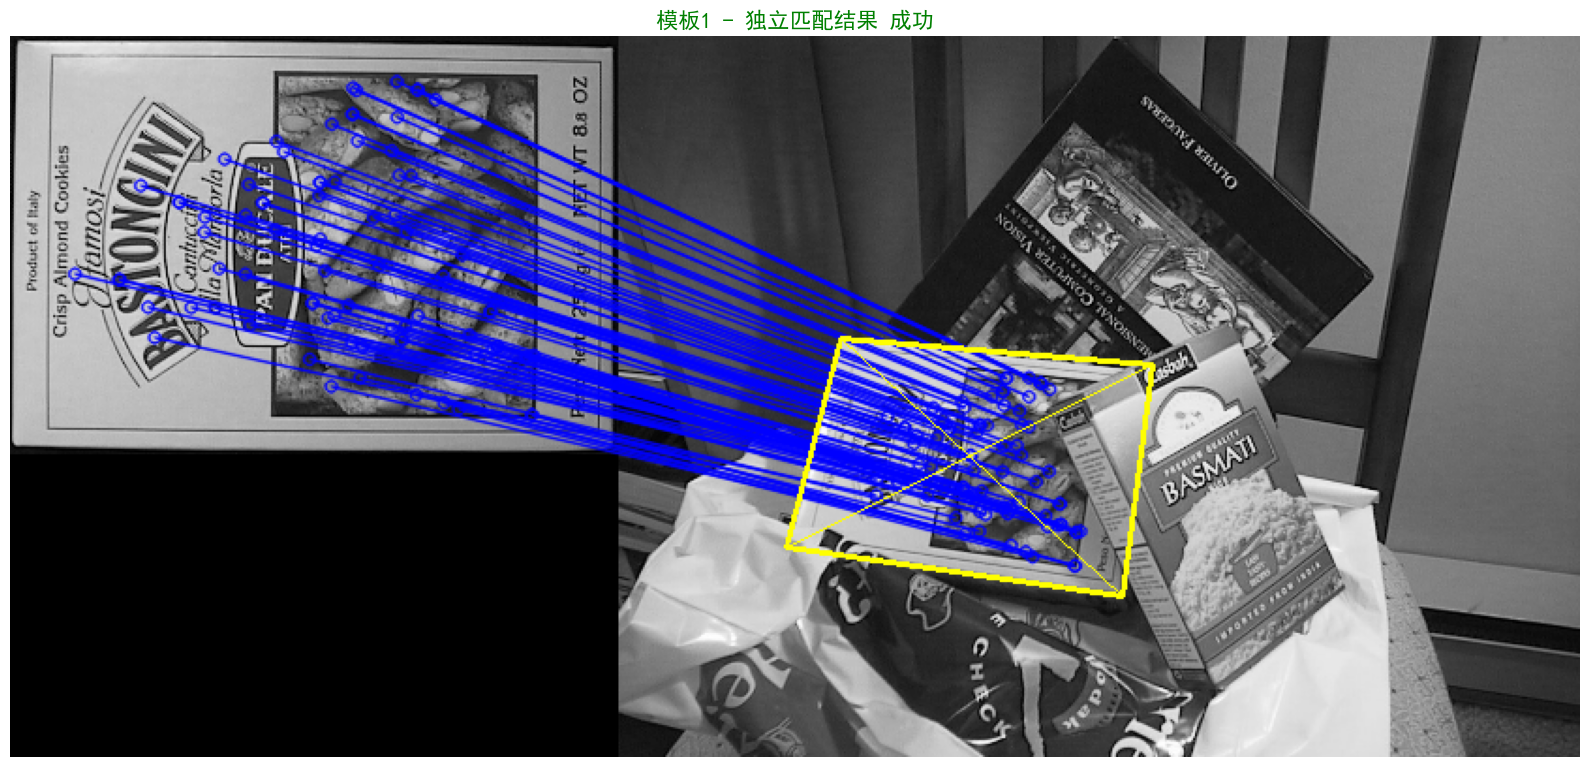

--------------------------------------------------
模板1 匹配统计
--------------------------------------------------
模板特征点数量：641 个
大图特征点数量：1046 个
优质匹配对数量：91 个
有效匹配对数量：80 个
匹配结果：成功
--------------------------------------------------
模板2：匹配成功，绘制113条特征匹配连线


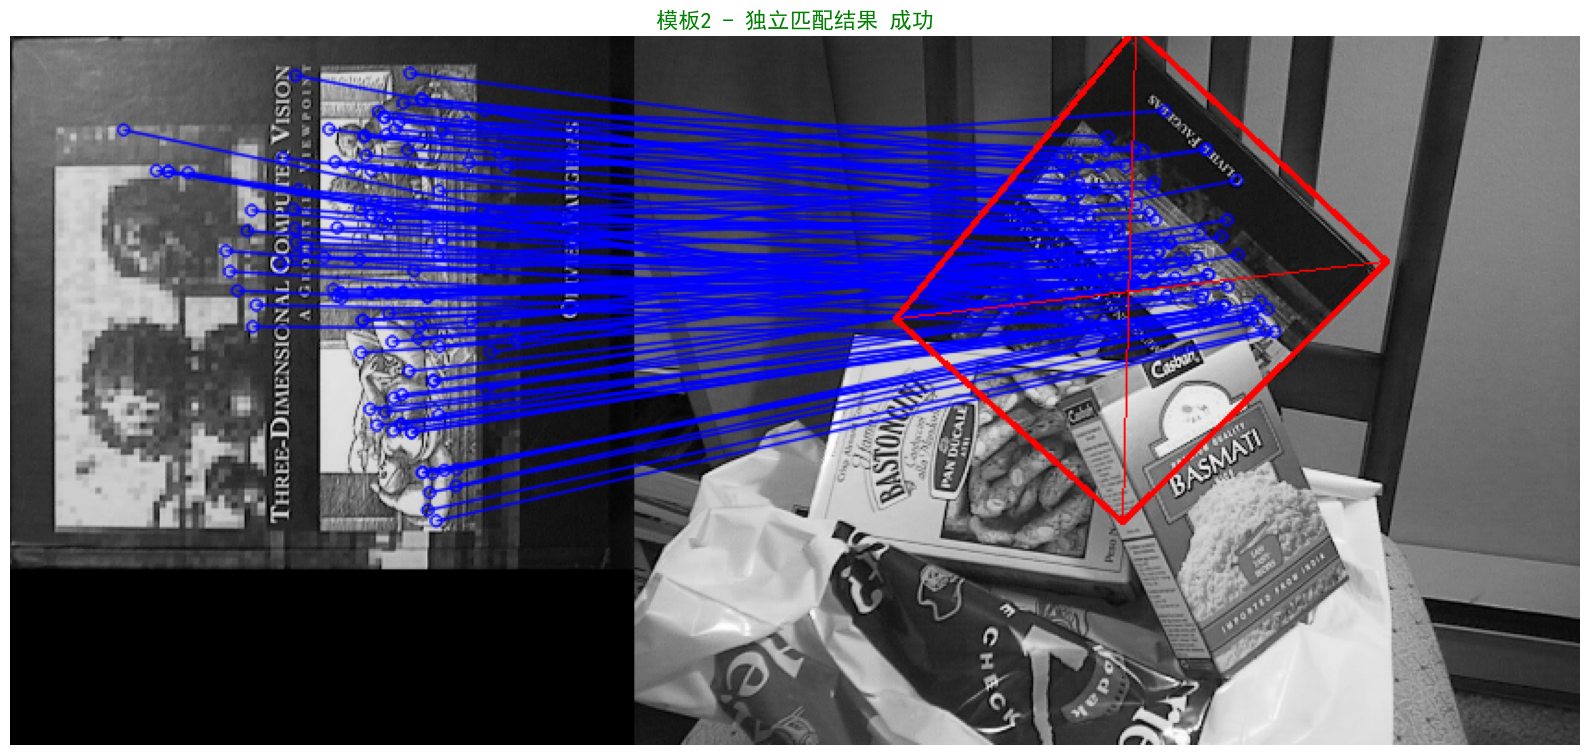

--------------------------------------------------
模板2 匹配统计
--------------------------------------------------
模板特征点数量：943 个
大图特征点数量：1046 个
优质匹配对数量：138 个
有效匹配对数量：113 个
匹配结果：成功
--------------------------------------------------
模板3：匹配成功，绘制48条特征匹配连线


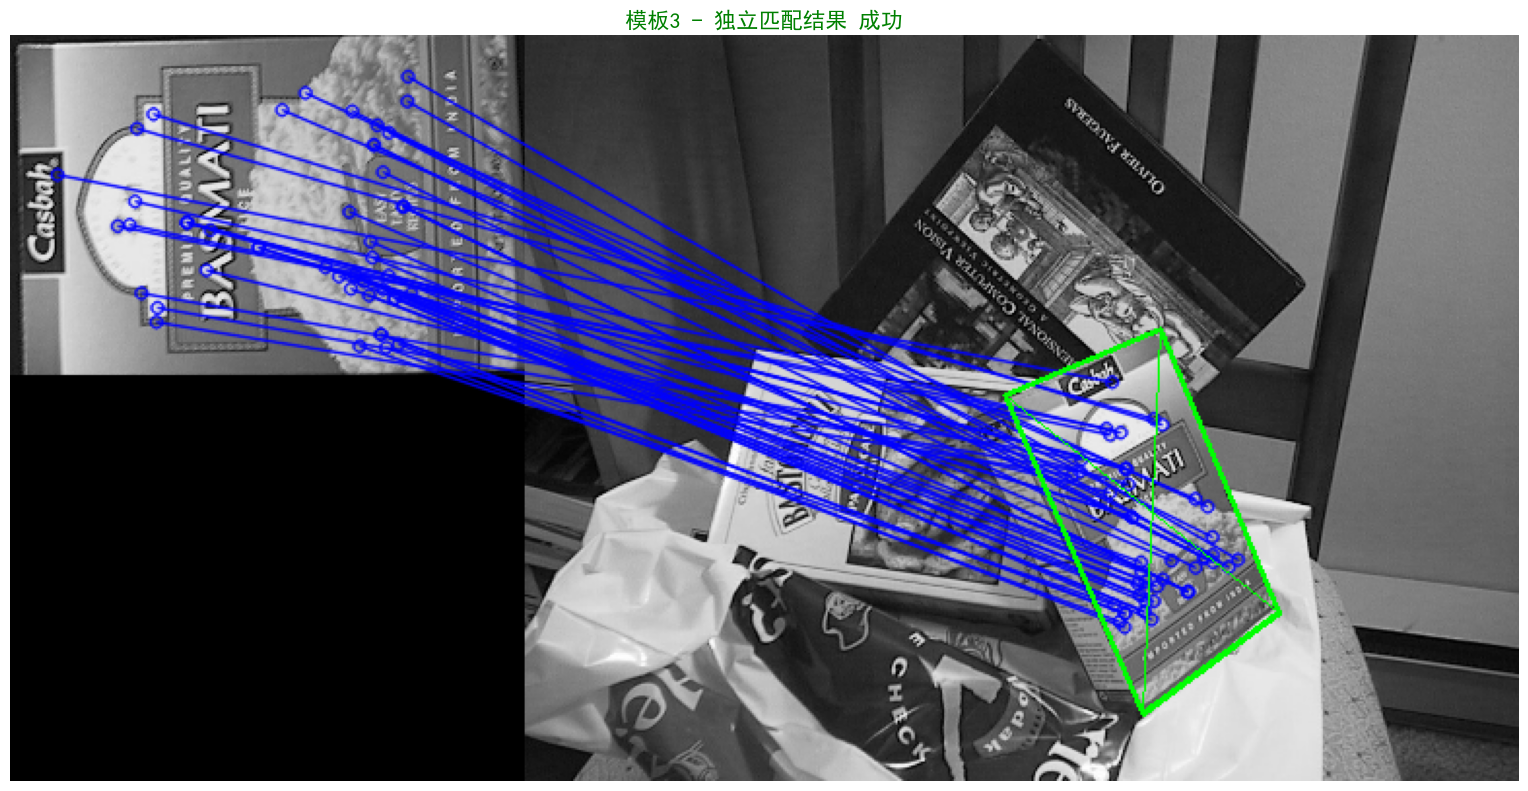

--------------------------------------------------
模板3 匹配统计
--------------------------------------------------
模板特征点数量：585 个
大图特征点数量：1046 个
优质匹配对数量：66 个
有效匹配对数量：48 个
匹配结果：成功
--------------------------------------------------

开始第4步：3模板一起匹配scene.png，生成汇总大图
模板1 → scene.png：匹配成功，已绘制定位框
模板2 → scene.png：匹配成功，已绘制定位框
模板3 → scene.png：匹配成功，已绘制定位框


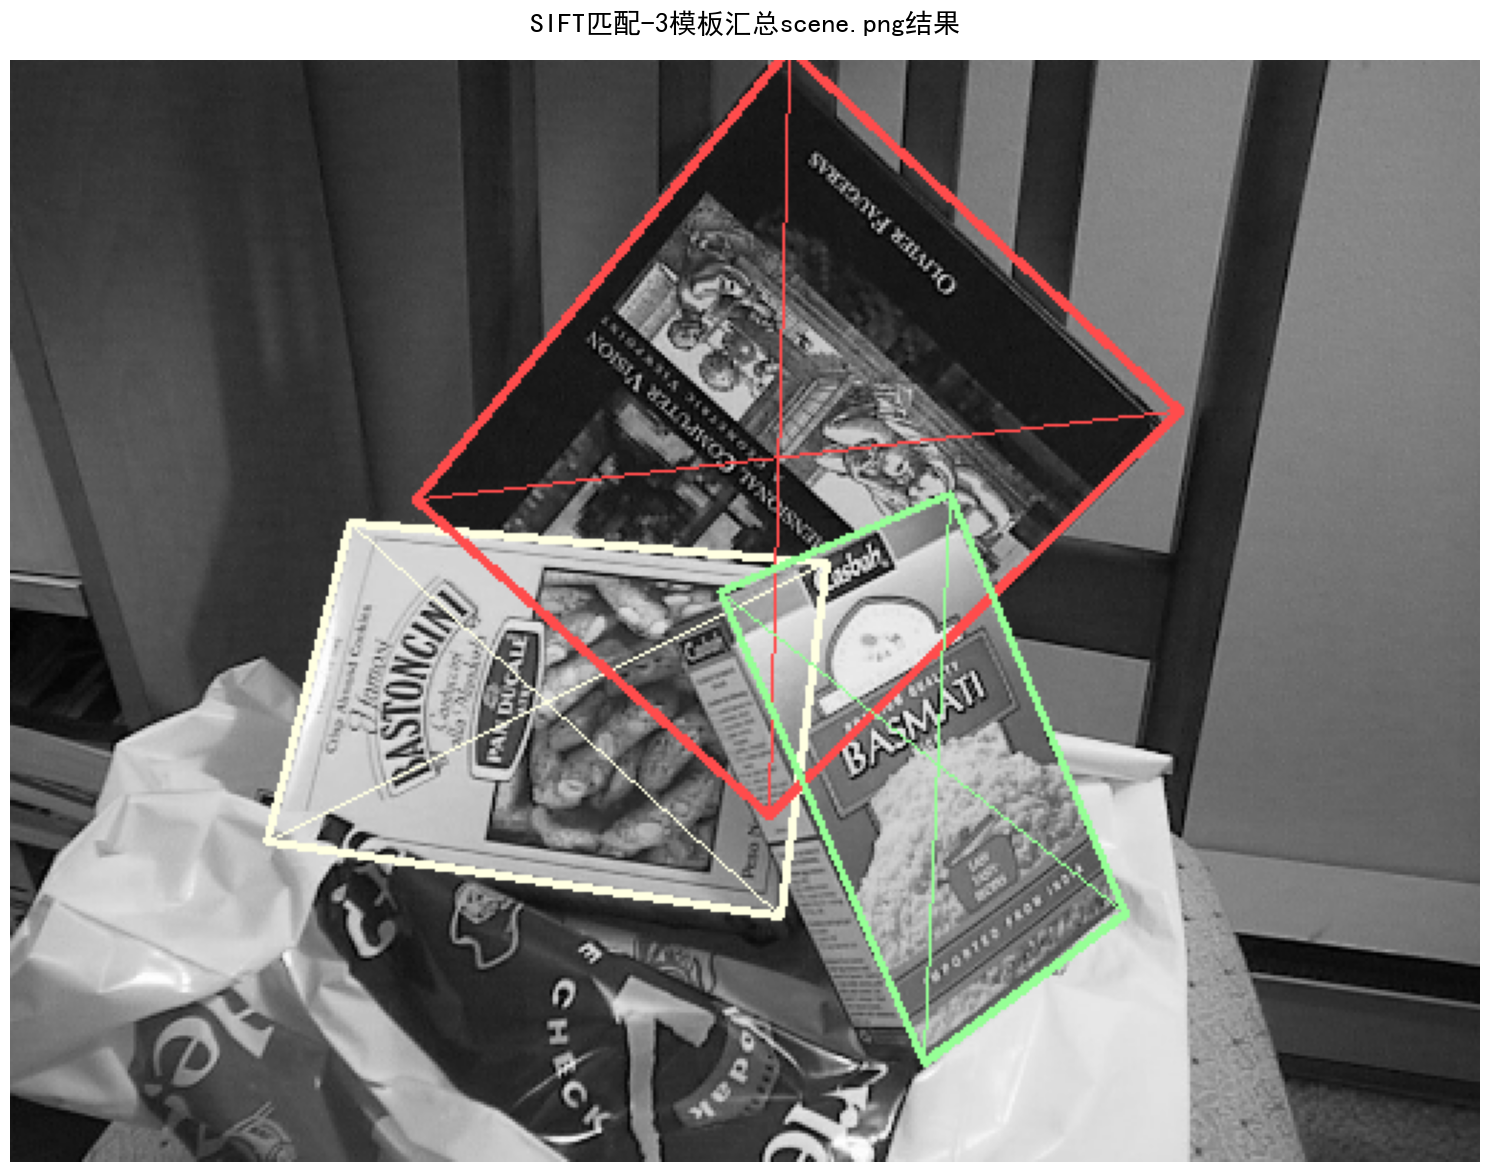


第4步完成：汇总大图生成成功！

所有流程完成！3张独立结果图 + 1张汇总结果图


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

# 初始化SIFT
sift = cv2.SIFT_create(
    nfeatures=0,
    nOctaveLayers=3,
    contrastThreshold=0.03,
    edgeThreshold=10,
    sigma=1.6
)

# 特征提取，支持pgm灰度图
def extract_sift_features(img_path):
    gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        raise FileNotFoundError(f"未找到图像文件：{img_path}，请检查路径是否正确")
    bgr_img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    kp, des = sift.detectAndCompute(gray_img, None)
    return bgr_img, gray_img, kp, des

# SIFT匹配+RANSAC验证
def sift_match_verify(tpl_kp, tpl_des, scene_kp, scene_des, ratio_thresh=0.8, reproj_thresh=4.0):
    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    raw_matches = matcher.knnMatch(tpl_des, scene_des, k=2)
    good_matches = [m for m, n in raw_matches if m.distance < ratio_thresh * n.distance]
    if len(good_matches) < 4:
        return good_matches, [], None
    tpl_pts = np.float32([tpl_kp[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    scene_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(tpl_pts, scene_pts, cv2.RANSAC, reproj_thresh)
    mask = mask.ravel().tolist()
    valid_matches = [good_matches[i] for i in range(len(good_matches)) if mask[i] == 1]
    return good_matches, valid_matches, H

# 绘制特征连线+论文风格定位框
def draw_match_result(tpl_img, scene_img, tpl_kp, scene_kp, valid_matches, H, tpl_color, line_color=(255, 0, 0)):
    # 绘制蓝色特征匹配连线
    match_img = cv2.drawMatches(
        tpl_img, tpl_kp,
        scene_img, scene_kp,
        valid_matches,
        None,
        matchColor=line_color,
        singlePointColor=None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    # 绘制定位框+内部交叉线
    h, w = tpl_img.shape[:2]
    tpl_corners = np.float32([[0,0], [w,0], [w,h], [0,h]]).reshape(-1,1,2)
    scene_corners = cv2.perspectiveTransform(tpl_corners, H)
    scene_corners[:, 0, 0] += tpl_img.shape[1]
    cv2.polylines(match_img, [np.int32(scene_corners)], True, tpl_color, 2)
    cv2.line(match_img, np.int32(scene_corners[0][0]), np.int32(scene_corners[2][0]), tpl_color, 1)
    cv2.line(match_img, np.int32(scene_corners[1][0]), np.int32(scene_corners[3][0]), tpl_color, 1)
    return match_img

# 单模板独立匹配，独立出图
def single_group_match(tpl_path, scene_path, tpl_name, color):
    try:
        tpl_bgr, _, tpl_kp, tpl_des = extract_sift_features(tpl_path)
        scene_bgr, _, scene_kp, scene_des = extract_sift_features(scene_path)
        good_matches, valid_matches, H = sift_match_verify(tpl_kp, tpl_des, scene_kp, scene_des)
        match_success = H is not None and len(valid_matches) >= 4

        if match_success:
            result_img = draw_match_result(tpl_bgr, scene_bgr, tpl_kp, scene_kp, valid_matches, H, color)
            print(f"{tpl_name}：匹配成功，绘制{len(valid_matches)}条特征匹配连线")
        else:
            result_img = np.hstack((tpl_bgr, scene_bgr))
            print(f"{tpl_name}：匹配失败，无有效特征点连线")

        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title(f"{tpl_name} - 独立匹配结果 {('成功' if match_success else '失败')}",
                  fontsize=16, fontweight='bold', color='green' if match_success else 'red')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        print(f"{'-'*50}")
        print(f"{tpl_name} 匹配统计")
        print(f"{'-'*50}")
        print(f"模板特征点数量：{len(tpl_kp)} 个")
        print(f"大图特征点数量：{len(scene_kp)} 个")
        print(f"优质匹配对数量：{len(good_matches)} 个")
        print(f"有效匹配对数量：{len(valid_matches)} 个")
        print(f"匹配结果：{'成功' if match_success else '失败'}")
        print(f"{'-'*50}")
        return match_success, tpl_bgr, H
    except Exception as e:
        print(f"\n{tpl_name} 处理失败：{str(e)}")
        return False, None, None

# 3模板汇总匹配，生成汇总大图
def total_match(tpl_config, total_scene_path):
    print("\n" + "="*60)
    print("开始第4步：3模板一起匹配scene.png，生成汇总大图")
    print("="*60)
    total_scene_bgr, total_scene_gray, total_scene_kp, total_scene_des = extract_sift_features(total_scene_path)
    total_result = total_scene_bgr.copy()  # 深拷贝，不修改原场景图像素
    for tpl_path, _, tpl_name, color in tpl_config:
        try:
            tpl_bgr, tpl_gray, tpl_kp, tpl_des = extract_sift_features(tpl_path)
            _, valid_matches, H = sift_match_verify(tpl_kp, tpl_des, total_scene_kp, total_scene_des)
            if H is not None and len(valid_matches) >= 4:
                h, w = tpl_bgr.shape[:2]
                tpl_corners = np.float32([[0,0], [w,0], [w,h], [0,h]]).reshape(-1,1,2)
                scene_corners = cv2.perspectiveTransform(tpl_corners, H)
                cv2.polylines(total_result, [np.int32(scene_corners)], True, color, 2)
                cv2.line(total_result, np.int32(scene_corners[0][0]), np.int32(scene_corners[2][0]), color, 1)
                cv2.line(total_result, np.int32(scene_corners[1][0]), np.int32(scene_corners[3][0]), color, 1)
                print(f"{tpl_name} → scene.png：匹配成功，已绘制定位框")
            else:
                print(f"{tpl_name} → scene.png：匹配失败，未绘制定位框")
        except Exception as e:
            print(f"{tpl_name} → scene.png：处理失败 → {str(e)}")

    plt.figure(figsize=(15, 12))
    gray_total = cv2.cvtColor(total_result, cv2.COLOR_BGR2GRAY)
    gray_total = cv2.cvtColor(gray_total, cv2.COLOR_GRAY2RGB)
    color_boxes = cv2.cvtColor(total_result, cv2.COLOR_BGR2RGB)
    gray_total[color_boxes != 0] = color_boxes[color_boxes != 0]
    plt.imshow(gray_total)
    plt.title('SIFT匹配-3模板汇总scene.png结果', fontsize=20, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("\n第4步完成：汇总大图生成成功！")

# 主函数（完全保留你的配置，无生成图代码，全改回PGM格式）
if __name__ == '__main__':
    SINGLE_MATCH_CONFIG = [
        ("box.pgm", "scene.pgm", "模板1", (0, 255, 255)),
        ("book.pgm", "scene.pgm", "模板2", (0, 0, 255)),
        ("basmati.pgm", "scene.pgm", "模板3", (0, 255, 0)),
    ]
    TOTAL_SCENE_PATH = "scene.pgm"

    # 3模板单独匹配，各出1张图
    print("开始前3步：3个模板单独匹配scene.pgm（各出1张结果图）...")
    for tpl_path, scene_path, tpl_name, color in SINGLE_MATCH_CONFIG:
        single_group_match(tpl_path, scene_path, tpl_name, color)

    # 3模板汇总匹配，出1张汇总图
    total_match(SINGLE_MATCH_CONFIG, TOTAL_SCENE_PATH)

    print("\n所有流程完成！3张独立结果图 + 1张汇总结果图")